# Analysis notebook for the modular addition experiment

Date: 04/03/2025

We have trained two models for the modular addition experiment:
1. MLP: A standard MLP model from the modular additional codebase..
2. MLP_IHVP: A MLP model adapted to with IHVP influence functions computed using Nina's codebase.

This notebook analyzes the NTK, Jacobian, IHVP, and influence matrices of these models.

You first need to run the train.py and train_mlp_ihvp.py scripts to train the models.


# Imports modules and models functions

In [1]:
import torch as t
from typing import List
import sys
import os
import numpy as np
import random
from pathlib import Path

parent_dir = os.path.abspath('..')
sys.path.insert(0, parent_dir)

from modular_addition.model import MLP
import modular_addition
modular_addition.MLP = MLP  # Make MLP accessible via modular_addition

modular_addition_path = os.path.abspath('../modular_addition')
sys.path.insert(0, modular_addition_path)

from model_mlp_ihvp import MLP_IHVP, ExperimentParams
from dataset import make_dataset, train_test_split, make_random_dataset
from compute_fourier_peakness import find_recursive_ntk_neighbors, compute_empirical_ntk, analyze_jacobian_fourier_peakiness, MLP, compute_eigenvalues
from influence_functions_mlp import get_query_grad, get_influences, dataset_sample, get_ekfac_factors_and_pseudo_grads, get_grads, get_ekfac_ihvp

seed_int = 422
t.manual_seed(seed_int)
np.random.seed(seed_int)
random.seed(seed_int)

# initialize models and params, load the models 

In [2]:
params = ExperimentParams(
    linear_1_tied=True,
    tie_unembed=False,
    movie=True,
    scale_linear_1_factor=1.0,
    scale_embed=1.0,
    use_random_dataset=False,
    freeze_middle=False,
    n_batches=16000,
    n_save_model_checkpoints=80,
    lr=0.005,
    magnitude=False,
    ablation_fourier=False,
    do_viz_weights_modes=False,
    batch_size=128,
    num_no_weight_decay_steps=0,
    weight_decay=0,
    run_id=0,
    activation="quad",
    hidden_size=32,
    embed_dim=12,
    train_frac=0.95
)
model_P_value = 53
model = MLP(params)

checkpoint_path = Path(modular_addition_path) / "models/checkpoints/CHECKPOINT_79_P53_frac0.95_hid32_emb12_tieunembedFalse_tielinTrue_freezeFalse_run0.pt"

# Load the model state
model.load_state_dict(t.load(checkpoint_path))
model.to(params.device)

params_ihvp = ExperimentParams(
    linear_1_tied=True,
    tie_unembed=False,
    movie=True,
    scale_linear_1_factor=1.0,
    scale_embed=1.0,
    use_random_dataset=False,
    freeze_middle=False,
    n_batches=16000,
    n_save_model_checkpoints=80,
    lr=0.005,
    magnitude=False,
    ablation_fourier=False,
    do_viz_weights_modes=False,
    batch_size=128,
    num_no_weight_decay_steps=0,
    weight_decay=0,
    run_id=0,
    activation="quad",
    hidden_size=32,
    embed_dim=12,
    train_frac=0.95
)

model_ihvp = MLP_IHVP(params_ihvp)

checkpoint_path = Path(modular_addition_path) / "models_mlp/checkpoints/CHECKPOINT_79_P53_frac0.95_hid32_emb12_tieunembedFalse_tielinTrue_freezeFalse_run0.pt"

# Load the model state
model_ihvp.load_state_dict(t.load(checkpoint_path))
model_ihvp.to(params_ihvp.device)

print(model)
print(model_ihvp)

MLP(
  (embedding): Embedding(53, 12)
  (linear1r): Linear(in_features=12, out_features=32, bias=True)
  (linear1l): Linear(in_features=12, out_features=32, bias=True)
  (linear2): Linear(in_features=32, out_features=53, bias=False)
)
MLP_IHVP(
  (embedding): Embedding(53, 12)
  (fc1): MLPBlock(
    (linear): Linear(in_features=12, out_features=32, bias=True)
  )
  (fc2): MLPBlock(
    (linear): Linear(in_features=32, out_features=53, bias=False)
  )
)


# Show the modes obtained by the embedding layer, we can see a few dominant modes in the picture.

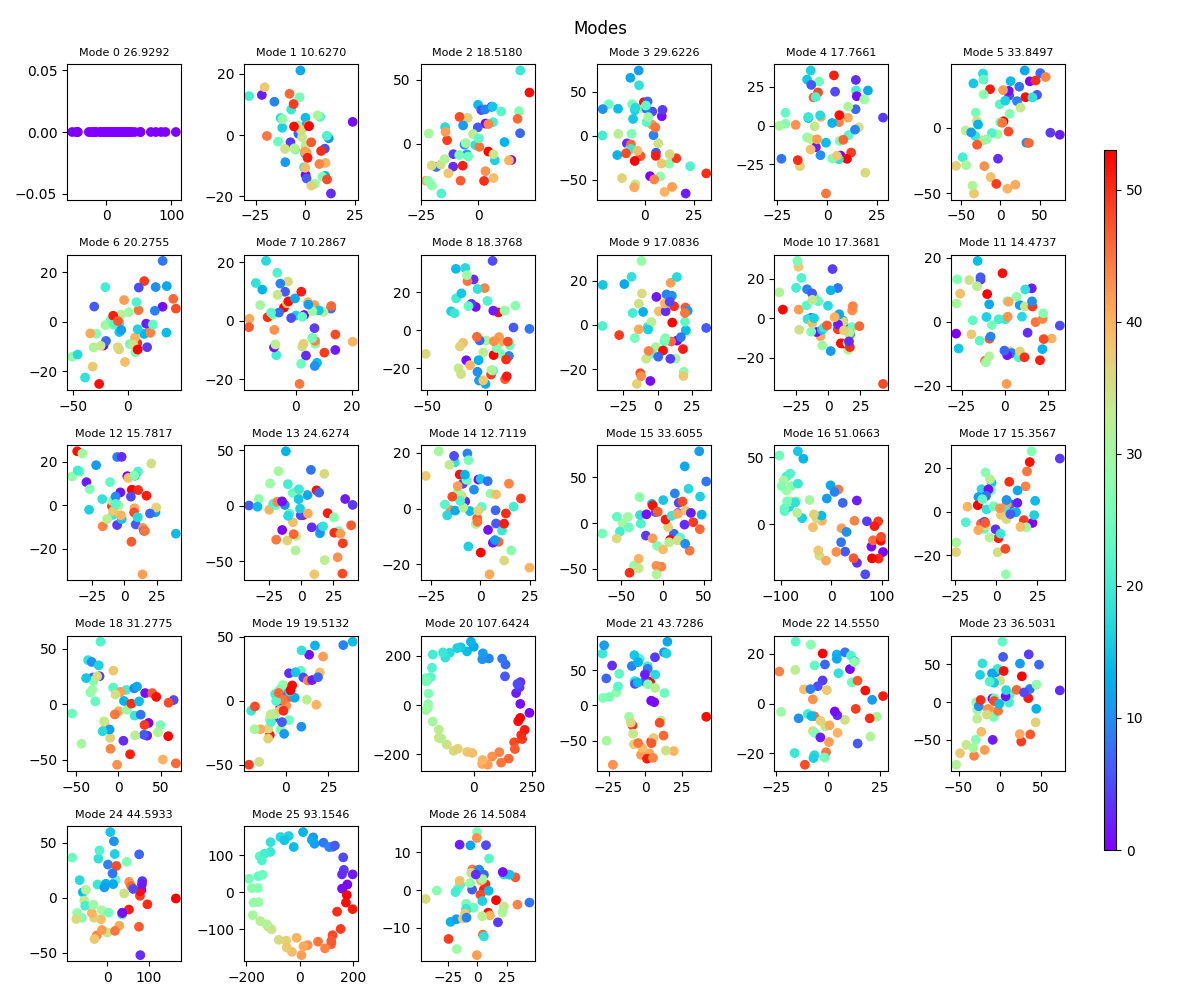

In [3]:
from IPython.display import Image, display

# Path to your PNG file
image_path = os.path.join(modular_addition_path, "frames/embeddings_movie_000099.png")

# Display the image
display(Image(filename=image_path))

# create the dataset to be used for analysis

In [4]:
if params.use_random_dataset:
    dataset = make_random_dataset(params.p, params.random_seed)
else:
    dataset = make_dataset(params.p)
train_data, test_data = train_test_split(
    dataset, params.train_frac, params.random_seed
)

print("num train data", len(train_data))
print("num test data", len(test_data))

First indices of shuffled dataset [2427, 2011, 1269, 1582, 2369, 1755, 2468, 186, 1077, 2448]
num train data 2668
num test data 141


# Compute the NTK matrix and the Jacobian matrix for the "standard" MLP model
# the NTK matrix has a few dominant eigenvalues, and it's effective dimension is 56, which closely matches the modular addition number 53

In [5]:
torch_matrix, nd_array, jacobian = compute_empirical_ntk(model, t.nn.CrossEntropyLoss(), train_data)
# ntk matrix is symmetric, so we can use the sum of the matrix and its transpose for eigenvalues for obtainingreal eigenvalues
sorted_eigenvals, effective_dim = compute_eigenvalues(nd_array + nd_array.T)
print("Sorted_eigenvals of the NTK matrix + its transpose", sorted_eigenvals[:50])
print("Effective dimension of the NTK matrix + its transpose", effective_dim, "out of", nd_array.shape[0])


Sorted_eigenvals of the NTK matrix + its transpose [2.96057635e-07 2.92848085e-07 2.50758148e-07 2.39297009e-07
 2.22103267e-07 1.85405142e-07 1.80536816e-07 1.57812636e-07
 1.46831411e-07 1.44414130e-07 1.42421598e-07 1.31737735e-07
 1.27297128e-07 1.19101614e-07 1.11767484e-07 1.10162752e-07
 1.01763987e-07 9.23096053e-08 8.84504061e-08 8.60748202e-08
 8.42270893e-08 8.30541182e-08 8.15899526e-08 7.87510217e-08
 7.57589547e-08 7.41012798e-08 7.08101595e-08 6.98368936e-08
 6.77630254e-08 6.51436594e-08 6.43215898e-08 6.18002005e-08
 5.87311604e-08 5.81002872e-08 5.52806156e-08 5.40740608e-08
 5.24257686e-08 5.09641431e-08 5.01202990e-08 4.77293298e-08
 4.69879815e-08 4.58146410e-08 4.44872299e-08 4.24869206e-08
 4.13371275e-08 3.97733508e-08 3.85511321e-08 3.68336721e-08
 3.56955603e-08 3.51482718e-08]
Effective dimension of the NTK matrix + its transpose 109.04348 out of 2668


/workspace/qft-nn/modular_addition/compute_fourier_peakness.py:282: RuntimeWarning: divide by zero encountered in divide
  decay_rates = sorted_eigenvals[1:] / sorted_eigenvals[:-1]
/workspace/qft-nn/modular_addition/compute_fourier_peakness.py:282: RuntimeWarning: invalid value encountered in divide
  decay_rates = sorted_eigenvals[1:] / sorted_eigenvals[:-1]


# compute a list of ntk circuit indices to be used for analysis

In [6]:
sampled_indices = np.random.choice(torch_matrix.shape[0], 5, replace=False).tolist()
num_neighbors = 20

list_of_ntk_circuit_indices = []
for start_idx in sampled_indices:
    circuit_indices = find_recursive_ntk_neighbors(
        torch_matrix, 
        start_idx,
        neighbors_per_step=3,
        total_neighbors=num_neighbors,
        strategy="last"
    )
    list_of_ntk_circuit_indices.append(circuit_indices)

print("list_of_ntk_circuit_indices", list_of_ntk_circuit_indices)

list_of_ntk_circuit_indices [[1770, 2643, 2061, 1012, 2563, 585, 135, 201, 2220, 521, 820, 608, 157, 2178, 1570, 1392, 2447, 714, 2252, 1940], [1070, 2267, 2553, 400, 2428, 1748, 410, 1233, 2522, 374, 2105, 1756, 701, 1871, 1552, 1272, 2102, 468, 157, 2178], [2609, 2515, 325, 1921, 2233, 2388, 1031, 1939, 1153, 542, 2190, 1908, 1743, 2539, 1505, 481, 1599, 312, 849, 2572], [423, 1729, 805, 2057, 551, 2166, 16, 1782, 494, 402, 1196, 1875, 317, 2164, 1584, 0, 760, 1316, 154, 227], [2640, 627, 2628, 17, 2148, 2644, 1364, 1286, 1206, 683, 1597, 922, 459, 2100, 1485, 1795, 2230, 1225, 1995, 1815]]


# This loop computes the SVD of the jacobian of the circuit examples nd also analyzes the peakiness in the fourier space for the embedding and linear1 layers.
# we compute the fft transform for each column of the embedding and linear1 layers and then find the top 5 modes that have the highest peakiness.
# we also compute the peakiness and concentration for the mean of the embedding and linear1 layers.

In [7]:
for circuit_indices in list_of_ntk_circuit_indices:

    # Analyze the Jacobian for this circuit
    jacobian_circuit = jacobian[circuit_indices]
    U, S, Vh = t.linalg.svd(jacobian_circuit)
    
    # Find the maximum singular value
    max_singular_value = S[0]
    
    # Count values less than 10% of the maximum
    threshold = 0.1 * max_singular_value
    small_values_count = (S < threshold).sum().item()
    small_values_percentage = (small_values_count / len(S)) * 100
    
    print(f"Max singular value: {max_singular_value:.4f}")
    print(f"Number of values < 10% of max: {small_values_count}/{len(S)} ({small_values_percentage:.1f}%)")
    
    # Optional: Analyze the top weight directions (right singular vectors)
    top_weight_directions = Vh[:3]  # Top 3 directions in weight space
    
    # TODO: You could further analyze these directions, e.g.:
    # 1. Identify which weights have the largest components
    # 2. Check if these align with specific Fourier modes
    # 3. Visualize the pattern of weights being used
    
    print("-" * 50)
    
    # Analyze Fourier peakiness of the circuit's gradients
    fourier_results, overall_results, magnitudes_embedding = analyze_jacobian_fourier_peakiness(jacobian_circuit, model, top_k_modes=5, module_name="embedding")
    
    # Print the most peaked parameters
    print(f"Fourier analysis for circuit starting at {start_idx}:")
    
    mag_sorted = magnitudes_embedding["mags"].sort(descending=True)
    print("top modes for embedding", mag_sorted.values)
    print("top indices for embedding", mag_sorted.indices)
    
    # Sort results by peakiness
    sorted_results = sorted(
        [(name, data) for name, data in fourier_results.items()],
        key=lambda x: x[1]['peakiness'],
        reverse=True
    )
    
    # Print top 5 most peaked parameters
    for name, data in sorted_results[:5]:
        print(f"  {name}:")
        print(f"    Top modes: {data['top_modes']}")
        print(f"    Peakiness: {data['peakiness']:.2f}")
        print(f"    Concentration: {data['concentration']:.2%}")
        
    print(f" top modes overall: {overall_results['overall']['top_modes']}")
    print(f" peakiness overall: {overall_results['overall']['peakiness']}")
    print(f" concentration overall: {overall_results['overall']['concentration']}")
    # Analyze Fourier peakiness of the circuit's gradients
    fourier_results, overall_results, magnitudes_linear1 = analyze_jacobian_fourier_peakiness(jacobian_circuit, model, top_k_modes=5, module_name="linear1")
    
    # Print the most peaked parameters
    print(f"Fourier analysis for circuit starting at {start_idx}:")
    
    # Sort results by peakiness
    sorted_results = sorted(
        [(name, data) for name, data in fourier_results.items()],
        key=lambda x: x[1]['peakiness'],
        reverse=True
    )
    
    # Print top 5 most peaked parameters
    for name, data in sorted_results[:5]:
        print(f"  {name}:")
        print(f"    Top modes: {data['top_modes']}")
        print(f"    Peakiness: {data['peakiness']:.2f}")
        print(f"    Concentration: {data['concentration']:.2%}")
        
    print(f" top modes overall: {overall_results['overall']['top_modes']}")
    print(f" peakiness overall: {overall_results['overall']['peakiness']}")
    print(f" concentration overall: {overall_results['overall']['concentration']}")

    print("-" * 50)

Max singular value: 0.0003
Number of values < 10% of max: 12/20 (60.0%)
--------------------------------------------------
Fourier analysis for circuit starting at 2640:
top modes for embedding tensor([3.5584e-06, 3.5584e-06, 3.4857e-06, 3.4856e-06, 2.8093e-06, 2.8093e-06,
        2.7939e-06, 2.7939e-06, 2.7394e-06, 2.7394e-06, 2.6604e-06, 2.6604e-06,
        2.5872e-06, 2.5872e-06, 2.4719e-06, 2.4719e-06, 2.3369e-06, 2.3369e-06,
        2.2605e-06, 2.2042e-06, 2.2042e-06, 2.1582e-06, 2.1582e-06, 2.1578e-06,
        2.1578e-06, 2.1082e-06, 2.1082e-06, 2.0854e-06, 2.0854e-06, 2.0814e-06,
        2.0814e-06, 2.0224e-06, 2.0224e-06, 1.9988e-06, 1.9988e-06, 1.9813e-06,
        1.9813e-06, 1.8727e-06, 1.8727e-06, 1.8155e-06, 1.8155e-06, 1.7571e-06,
        1.7571e-06, 1.7483e-06, 1.7483e-06, 1.6744e-06, 1.6744e-06, 1.5298e-06,
        1.5298e-06, 1.5266e-06, 1.5266e-06, 1.0946e-06, 1.0946e-06],
       device='cuda:0')
top indices for embedding tensor([36, 17, 50,  3, 14, 39, 40, 13, 34, 19,

# evaluation of the IHVP and influence

In [8]:
model_ihvp.eval()
n_queries = 10
queries = dataset_sample(test_data, n_queries)
gradient_fitting_data = dataset_sample(train_data, len(train_data))
search_data = dataset_sample(train_data, len(train_data))

mlp_blocks = [model_ihvp.fc1, model_ihvp.fc2]


topk = 10
print("len of queries", len(queries))
print("len of gradient fitting data", len(gradient_fitting_data))
print("len of search data", len(search_data))
print("first 5 queries", queries[0:5])
print("first 5 gradient fitting data", gradient_fitting_data[0:5])
print("first 5 search data", search_data[0:5])


len of queries 10
len of gradient fitting data 2668
len of search data 2668
first 5 queries [((tensor(26), tensor(28)), tensor(1)), ((tensor(6), tensor(30)), tensor(36)), ((tensor(27), tensor(8)), tensor(35)), ((tensor(23), tensor(34)), tensor(4)), ((tensor(18), tensor(49)), tensor(14))]
first 5 gradient fitting data [((tensor(41), tensor(41)), tensor(29)), ((tensor(48), tensor(37)), tensor(32)), ((tensor(6), tensor(43)), tensor(49)), ((tensor(34), tensor(26)), tensor(7)), ((tensor(8), tensor(44)), tensor(52))]
first 5 search data [((tensor(35), tensor(6)), tensor(41)), ((tensor(41), tensor(15)), tensor(3)), ((tensor(43), tensor(41)), tensor(31)), ((tensor(37), tensor(21)), tensor(5)), ((tensor(33), tensor(45)), tensor(25))]


# we compute ihvp matrix and ntk matrix for the ihvp model
# note that the effective dimension of the ihvp matrix is 100, which is larger than the modular addition number 53
# this number varies between different runs

In [9]:
kfac_input_covs, kfac_grad_covs, pseudo_grads = get_ekfac_factors_and_pseudo_grads(
    model_ihvp, gradient_fitting_data, mlp_blocks, params.device
)

search_grads = get_grads(model_ihvp, search_data, mlp_blocks, params.device)

ihvp = get_ekfac_ihvp(kfac_input_covs, kfac_grad_covs, pseudo_grads, search_grads)

print("ihvp.shape", ihvp.shape)

torch_matrix, nd_array, jacobian = compute_empirical_ntk(model_ihvp, t.nn.CrossEntropyLoss(), train_data)

print("torch_matrix.shape", torch_matrix.shape)
print("nd_array.shape", nd_array.shape)
print("jacobian.shape", jacobian.shape)

sorted_eigenvals, effective_dim = compute_eigenvalues(torch_matrix + torch_matrix.T)
print("Sorted_eigenvals of the NTK matrix + its transpose", sorted_eigenvals[:50])
print("Effective dimension of the NTK matrix + its transpose", effective_dim, "out of", nd_array.shape[0])


ihvp.shape torch.Size([2668, 2165])
torch_matrix.shape torch.Size([2668, 2668])
nd_array.shape (2668, 2668)
jacobian.shape torch.Size([2668, 2748])
Sorted_eigenvals of the NTK matrix + its transpose [7.2401525e-07 5.4496996e-07 4.5320886e-07 3.8280135e-07 3.3531930e-07
 3.1291887e-07 3.0714577e-07 2.7151373e-07 2.6770718e-07 2.3047780e-07
 2.2083350e-07 2.1639053e-07 2.0838471e-07 1.9729865e-07 1.9188872e-07
 1.8130261e-07 1.7303149e-07 1.7003761e-07 1.6127817e-07 1.5204566e-07
 1.4418455e-07 1.3464633e-07 1.2559869e-07 1.1727990e-07 1.0719179e-07
 1.0489956e-07 1.0155116e-07 9.8045291e-08 9.6443202e-08 9.3019715e-08
 8.5882270e-08 8.2800156e-08 8.1543554e-08 7.7601726e-08 7.6211023e-08
 7.6137233e-08 7.3056391e-08 7.2369858e-08 6.9453144e-08 6.7654184e-08
 6.5413325e-08 6.3677007e-08 6.0317369e-08 5.8300518e-08 5.7017552e-08
 5.5185705e-08 5.4347669e-08 5.2415949e-08 5.0343711e-08 4.9161109e-08]
Effective dimension of the NTK matrix + its transpose 101.51793 out of 2668


/workspace/qft-nn/modular_addition/compute_fourier_peakness.py:282: RuntimeWarning: divide by zero encountered in divide
  decay_rates = sorted_eigenvals[1:] / sorted_eigenvals[:-1]
/workspace/qft-nn/modular_addition/compute_fourier_peakness.py:282: RuntimeWarning: invalid value encountered in divide
  decay_rates = sorted_eigenvals[1:] / sorted_eigenvals[:-1]


# compute the svd of the ihvp matrix, ntk jacobian, and the influences matrix
# the distribution of singular values of the ihvp matrix and ntk jacobian are similar, and the effective dimension is around 400 for both
# the distribution of singular values of the influences matrix is more concentrated, and the effective dimension is around 200

In [10]:
U, S, Vh = t.linalg.svd(ihvp)
# Find the maximum singular value
max_singular_value = S[0]
print("top 50 singular values for ihvp", S[:50])
# Count values less than 10% of the maximum
threshold = 0.1 * max_singular_value
small_values_count = (S < threshold).sum().item()
small_values_percentage = (small_values_count / len(S)) * 100

print(f"Max singular value for ihvp: {max_singular_value:.4f}")
print(f"Number of values < 10% of max for ihvp: {small_values_count}/{len(S)} ({small_values_percentage:.1f}%)")

# Normalize eigenvalues to create a probability distribution
S_numpy = S.detach().cpu().numpy()
total = np.sum(S_numpy)
normalized_singular_values = S_numpy / total

# compute entropy and effective dimension
nonzero_probs = normalized_singular_values[normalized_singular_values > 0]
entropy = -np.sum(nonzero_probs * np.log(nonzero_probs))
effective_dim = np.exp(entropy)

print(f"Effective dimension for ihvp: {effective_dim:.2f} (out of {len(S)})")

U, S, Vh = t.linalg.svd(jacobian)
# Find the maximum singular value
max_singular_value = S[0]
print("top 50 singular values for jacobian", S[:50])
# Count values less than 10% of the maximum
threshold = 0.1 * max_singular_value
small_values_count = (S < threshold).sum().item()
small_values_percentage = (small_values_count / len(S)) * 100

print(f"Max singular value for jacobian: {max_singular_value:.4f}")
print(f"Number of values < 10% of max for jacobian: {small_values_count}/{len(S)} ({small_values_percentage:.1f}%)")

# Normalize eigenvalues to create a probability distribution
S_numpy = S.detach().cpu().numpy()
total = np.sum(S_numpy)
normalized_singular_values = S_numpy / total
# compute entropy and effective dimension
nonzero_probs = normalized_singular_values[normalized_singular_values > 0]
entropy = -np.sum(nonzero_probs * np.log(nonzero_probs))
effective_dim = np.exp(entropy)

print(f"Effective dimension for jacobian: {effective_dim:.2f} (out of {len(S)})")


top 50 singular values for ihvp tensor([6.0140e-07, 5.2168e-07, 4.7540e-07, 4.3698e-07, 4.0838e-07, 3.9462e-07,
        3.9092e-07, 3.6777e-07, 3.5877e-07, 3.3861e-07, 3.3099e-07, 3.2753e-07,
        3.2197e-07, 3.1272e-07, 3.0935e-07, 3.0058e-07, 2.9360e-07, 2.9125e-07,
        2.8344e-07, 2.7526e-07, 2.6774e-07, 2.5871e-07, 2.4950e-07, 2.4159e-07,
        2.3082e-07, 2.2819e-07, 2.2443e-07, 2.2075e-07, 2.1861e-07, 2.1475e-07,
        2.0578e-07, 2.0275e-07, 2.0101e-07, 1.9615e-07, 1.9441e-07, 1.9405e-07,
        1.8992e-07, 1.8876e-07, 1.8394e-07, 1.8255e-07, 1.7974e-07, 1.7721e-07,
        1.7268e-07, 1.7012e-07, 1.6774e-07, 1.6545e-07, 1.6353e-07, 1.6083e-07,
        1.5742e-07, 1.5570e-07], device='cuda:0')
Max singular value for ihvp: 0.0000
Number of values < 10% of max for ihvp: 2027/2165 (93.6%)
Effective dimension for ihvp: 352.23 (out of 2165)
top 50 singular values for jacobian tensor([0.0006, 0.0005, 0.0005, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004, 0.0004,
        0.0003, 0

/tmp/ipykernel_21280/1568328966.py:25: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:690.)
  U, S, Vh = t.linalg.svd(jacobian)


In [11]:
query_grads = []
for i, data in enumerate(search_data):
    query_grad = get_query_grad(model_ihvp, data, mlp_blocks, params.device)
    query_grads.append(query_grad)
query_grads = t.stack(query_grads)
influences_matrix = ihvp @ query_grads.T

U, S, Vh = t.linalg.svd(influences_matrix)
# Find the maximum singular value
max_singular_value = S[0]
print("singular values for influences_matrix", S[:50])
# Count values less than 10% of the maximum
threshold = 0.1 * max_singular_value
small_values_count = (S < threshold).sum().item()
small_values_percentage = (small_values_count / len(S)) * 100

print(f"Max singular value for influences_matrix: {max_singular_value:.4f}")
print(f"Number of values < 10% of max for influences_matrix: {small_values_count}/{len(S)} ({small_values_percentage:.1f}%)")

# Normalize eigenvalues to create a probability distribution
S_numpy = S.detach().cpu().numpy()
total = np.sum(S_numpy)
normalized_singular_values = S_numpy / total
# compute entropy and effective dimension
nonzero_probs = normalized_singular_values[normalized_singular_values > 0]
entropy = -np.sum(nonzero_probs * np.log(nonzero_probs))

effective_dim = np.exp(entropy)

print(f"Effective dimension for influences_matrix: {effective_dim:.2f} (out of {len(S)})")

singular values for influences_matrix tensor([5.9970e-11, 4.2191e-11, 3.4063e-11, 2.9864e-11, 2.9382e-11, 2.4757e-11,
        2.3096e-11, 2.0235e-11, 1.9581e-11, 1.9173e-11, 1.8288e-11, 1.7835e-11,
        1.7509e-11, 1.5924e-11, 1.4935e-11, 1.4209e-11, 1.3729e-11, 1.3570e-11,
        1.2942e-11, 1.2504e-11, 1.2305e-11, 1.1686e-11, 1.1317e-11, 1.1125e-11,
        1.0828e-11, 1.0532e-11, 1.0070e-11, 9.7802e-12, 9.6017e-12, 9.3106e-12,
        8.6990e-12, 8.5536e-12, 8.5451e-12, 8.2438e-12, 8.1535e-12, 8.1427e-12,
        7.7648e-12, 7.6518e-12, 7.4365e-12, 7.3960e-12, 7.2092e-12, 6.8922e-12,
        6.8294e-12, 6.7246e-12, 6.6189e-12, 6.3536e-12, 6.2436e-12, 6.1453e-12,
        5.9077e-12, 5.8170e-12], device='cuda:0')
Max singular value for influences_matrix: 0.0000
Number of values < 10% of max for influences_matrix: 2620/2668 (98.2%)
Effective dimension for influences_matrix: 158.82 (out of 2668)
